# 5.1

In [1]:
import json
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import os

In [2]:
# Set plotting style
sns.set_theme(style="whitegrid")

# Load data
# We assume the notebook is located in 'QueueTorch/notebooks' and results in 'QueueTorch/results'
results_path = '../results/gradient_comparison.json'


with open(results_path, 'r') as f:
    data = json.load(f)

df = pd.DataFrame(data)

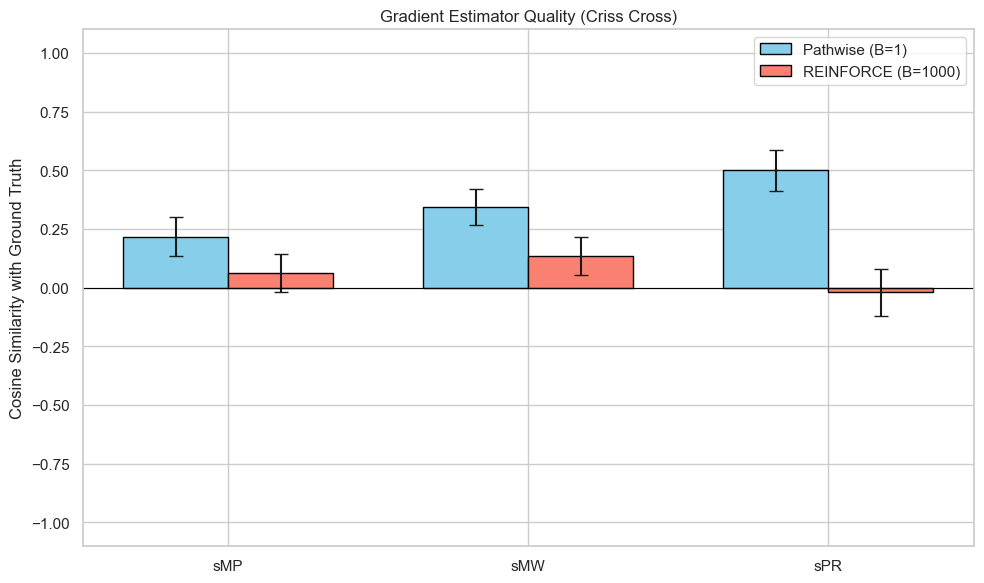

In [3]:
# The user requested to reproduce the figure "only on the criss_cross part".
# The gradient_comparison.json typically contains results for the environment configured in the experiment.
# Based on the project context, we assume this data corresponds to the Criss Cross environment.

# Drop samples where gradients were invalid (NaN)
df = df.dropna()

# Calculate Mean and Standard Error (SEM) for each policy
grouped = df.groupby('policy')[['sim_pathwise', 'sim_reinforce']].agg(['mean', 'sem'])

# Setup plot
policies = grouped.index
x = np.arange(len(policies))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))

# Plot Pathwise (Blue)
rects1 = ax.bar(x - width/2, grouped['sim_pathwise']['mean'], width,
                yerr=grouped['sim_pathwise']['sem'], label='Pathwise (B=1)', capsize=5,
                color='skyblue', edgecolor='black')

# Plot REINFORCE (Red)
rects2 = ax.bar(x + width/2, grouped['sim_reinforce']['mean'], width,
                yerr=grouped['sim_reinforce']['sem'], label='REINFORCE (B=1000)', capsize=5,
                color='salmon', edgecolor='black')

# Formatting
ax.set_ylabel('Cosine Similarity with Ground Truth')
ax.set_title('Gradient Estimator Quality (Criss Cross)')
ax.set_xticks(x)
ax.set_xticklabels(policies)
ax.legend()

# Y-axis range [-1, 1]
ax.set_ylim(-1.1, 1.1)
ax.axhline(0, color='black', linewidth=0.8)

plt.tight_layout()
plt.show()


# 5.2

pw5: {0: [-0.06198301911354065, 0.031726885586977005, -0.06800025701522827, 0.00801820494234562, 0.04851122573018074, -0.047759898006916046, -0.023741820827126503, -0.023778600618243217, -0.02062261663377285, 0.0010982344392687082, 0.028612179681658745, -0.004648578353226185, 0.007334764581173658, -0.015359225682914257, 0.010431494563817978, -0.030517306178808212, 0.03001910261809826, -0.022829871624708176, -0.023083927109837532, -0.021968329325318336, 0.008616136386990547, -0.016900684684515, 0.002071049530059099, 0.02489379607141018, -0.029849912971258163, 0.01374431699514389, -0.012747440487146378, -0.008216824382543564, 0.020364945754408836, 0.03272383660078049, 0.05177747830748558, 0.015080524608492851, -0.0015592023264616728, -0.00757197430357337, 0.01524266880005598, -0.040436334908008575, 0.023829540237784386, 0.05403356999158859, 0.014405324123799801, -0.003677703207358718, -0.006406027358025312, 0.015446063131093979, -0.0013974332250654697, 0.013329394161701202, -0.0319730117

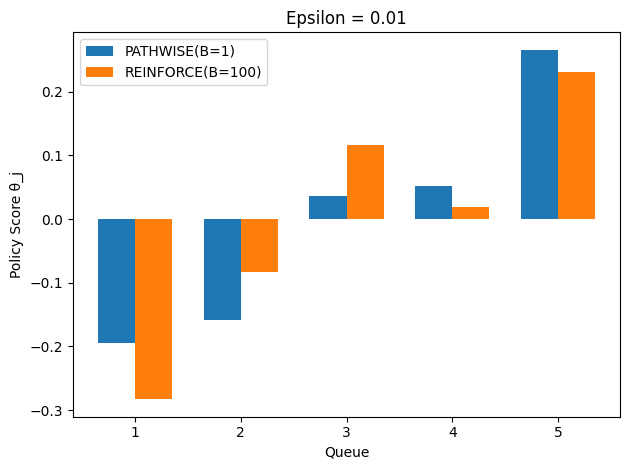

In [19]:
import json
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict
# Section 5.2 
## Fig 9.1

with open("/user/xz3355/QueueTorchReviews/cmu/pathwise_wc_cmu_multiclass5_all_eps.json", "r") as f:
    pw5 = json.load(f)
    
with open("/user/xz3355/QueueTorchReviews/cmu/wc_reinforce_baseline_cmu_B100_multiclass5_all_eps.json", "r") as f:
    rf5 = json.load(f)
    
alphas = ["0.01", "0.1", "0.5", "1.0"]
gaps = ['0.01'] # [1, 0.5, 0.1, 0.05, 0.01]
n = 5
pw5_results = {}
pw5_count = 0
rf5_results = {}
rf5_count = 0

for i in range(n):
    pw5_results[i] = []
    rf5_results[i] = []
    
for alpha in alphas:
    for gap in gaps:
        for x in pw5[alpha][gap]:
            pw5_count += 1
            for i in range(n):
                pw5_results[i].append(x['last_iterate'][0][i])
        for x in rf5[alpha][gap]:
            rf5_count += 1
            for i in range(n):
                rf5_results[i].append(x['last_iterate'][0][i])

print('pw5:', pw5_results)
print('pw5_count:', pw5_count)
pw5_avg_results = [sum(x)/pw5_count for x in pw5_results.values()]
rf5_avg_results = [sum(x)/rf5_count for x in rf5_results.values()]

print(f"Average Policy Score for PATHWISE: {pw5_avg_results}")
print(f"Average Policy Score for REINFORCE: {rf5_avg_results}")

x = np.arange(n)      
width = 0.35              

plt.bar(x - width/2, pw5_avg_results, width, label='PATHWISE(B=1)')
plt.bar(x + width/2, rf5_avg_results, width, label='REINFORCE(B=100)')

plt.title("Epsilon = 0.01")
plt.xticks(x, ['1', '2', '3', '4', '5'])
plt.xlabel('Queue')
plt.ylabel('Policy Score θ_j')
plt.legend()

plt.tight_layout()
plt.show() 
# plt.savefig("/user/xz3355/QueueTorchReviews/cmu/Fig9_1.png")



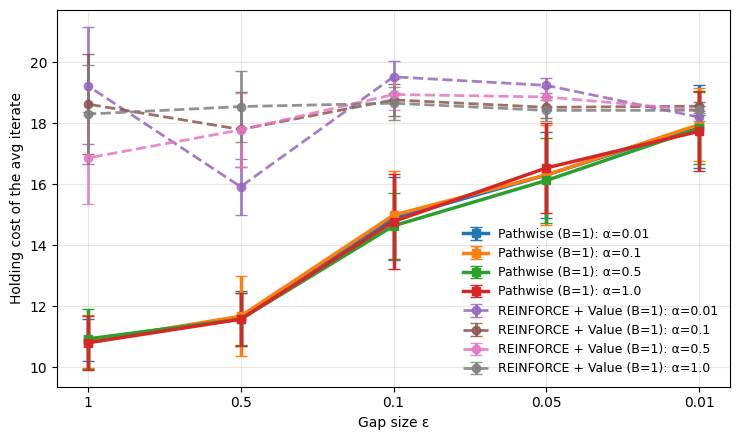

In [11]:
## Fig9.2
alphas = [0.01, 0.1, 0.5, 1.0]
gaps = [1, 0.5, 0.1, 0.05, 0.01]

# with open("/user/xz3355/queue-learning/cmu/pathwise_wc_cmu_multiclass.json", 'r') as f:
with open("/user/xz3355/QueueTorchReviews/cmu/pathwise_wc_cmu1_multiclass10.json", "r") as f:
    pw10 = json.load(f)
   
# with open("/user/xz3355/queue-learning/cmu/wc_reinforce_baseline_cmu_multiclass.json", "r") as f: 
with open("/user/xz3355/QueueTorchReviews/cmu/wc_reinforce_baseline_cmu_B1_multiclass10.json", "r") as f:
    rf10 = json.load(f)

pw10_results = []
rf10_results = []
pw10_count = 0
rf10_count = 0

for alpha in alphas:
    for gap in gaps:
        pw10_cost_list = []
        rf10_cost_list = []
        
        for x in pw10[str(alpha)][str(gap)]:
            pw10_count += 1
            pw10_cost_list.append(x['avg_cost'])
            
        for x in rf10[str(alpha)][str(gap)]:
            rf10_count += 1
            rf10_cost_list.append(x['avg_cost'])

        pw10_results.append({'alpha':alpha, 'gap': gap, 'avg_cost': np.mean(pw10_cost_list), 'cost_std': 1.96*np.std(pw10_cost_list)})
        rf10_results.append({'alpha':alpha, 'gap': gap, 'avg_cost': np.mean(rf10_cost_list), 'cost_std': 1.96*np.std(rf10_cost_list)/10})


fig, ax = plt.subplots(figsize=(7.5, 4.5))
x = list(range(len(gaps))) 
gaps = sorted(gaps, reverse=False)

# ===== 1. Pathwise =====
pw_by_alpha = defaultdict(list)
for r in pw10_results:
    pw_by_alpha[r['alpha']].append(r)

for alpha, records in pw_by_alpha.items():
    records = sorted(records, key=lambda x: x['gap'], reverse=False)

    # gaps  = [r['gap'] for r in records]
    means = [r['avg_cost'] for r in records]
    stds  = [r['cost_std'] for r in records]

    ax.errorbar(
        x, means, yerr=stds,
        marker='s',
        linestyle='-',
        linewidth=2.5,
        capsize=4,
        label=f"Pathwise (B=1): α={alpha}"
    )

# ===== 2. REINFORCE =====
rf_by_alpha = defaultdict(list)
for r in rf10_results:
    rf_by_alpha[r['alpha']].append(r)

for alpha, records in rf_by_alpha.items():
    records = sorted(records, key=lambda x: x['gap'], reverse=False)

    # gaps  = [r['gap'] for r in records]
    means = [r['avg_cost'] for r in records]
    stds  = [r['cost_std'] for r in records]

    ax.errorbar(
        x, means, yerr=stds,
        marker='o',
        linestyle='--',
        linewidth=2,
        capsize=4,
        alpha=0.85,
        label=f"REINFORCE + Value (B=1): α={alpha}"
    )

# ===== 3. graph style =====
ax.set_xticks(x)
ax.set_xticklabels(gaps)
ax.set_xlabel("Gap size ε")
ax.set_ylabel("Holding cost of the avg iterate")
ax.invert_xaxis()
ax.grid(True, alpha=0.3)
ax.legend(frameon=False, fontsize=9)
plt.tight_layout()
plt.show()
# plt.savefig("/user/xz3355/QueueTorchReviews/cmu/Fig9_2.png")

# 5.3

In [7]:
# Load data for admission control summary
summary_path = '../results/admission_control_like_buffer_summary.json'

with open(summary_path, 'r') as f:
    summary_data = json.load(f)

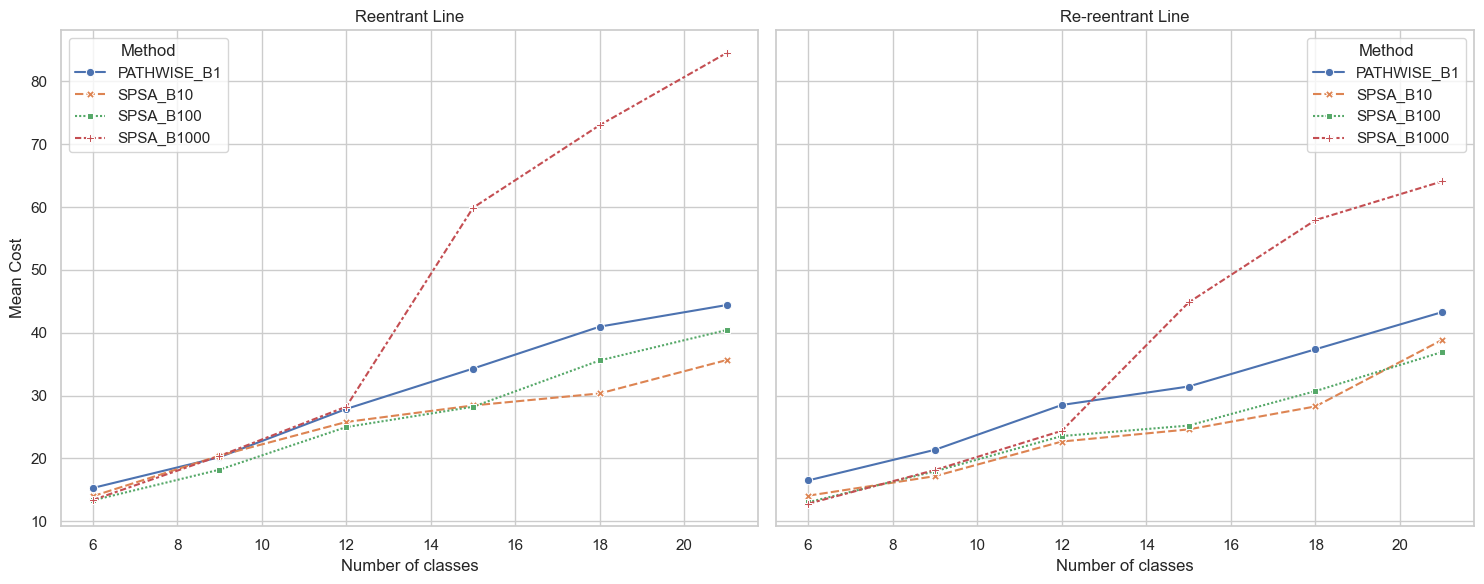

In [9]:
# Extract data for plotting
# We want to plot Mean Cost vs Number of Servers (or Hyper-parameter index)
# The keys are like "reentrant_2_hyper.yaml", "reentrant_3_hyper.yaml", etc.
# We'll extract the number (2, 3, 4...) as the x-axis.

# Separate data into two groups: "reentrant" and "re-reentrant"
reentrant_data = {}
rereentrant_data = {}

for key, value in summary_data.items():
    # Parse key to get type and index
    parts = key.split('_')
    # parts[0] is 'reentrant' or 're-reentrant' (actually 're-reentrant' splits to ['re-reentrant', ...])
    # Let's handle carefully.

    if key.startswith('re-reentrant'):
        idx = int(parts[1][0])*3 # 're-reentrant_2_hyper.yaml' -> parts=['re-reentrant', '2', 'hyper.yaml']
        rereentrant_data[idx] = value
    elif key.startswith('reentrant'):
        idx = int(parts[1][0])*3 # 'reentrant_2_hyper.yaml' -> parts=['reentrant', '2', 'hyper.yaml']
        reentrant_data[idx] = value

# Function to prepare dataframe for plotting
def prepare_df(data_dict):
    rows = []
    for idx, methods in data_dict.items():
        for method, stats in methods.items():
            rows.append({
                'Index': idx,
                'Method': method,
                'Mean': stats['mean'],
                'Std': stats['std']
            })
    return pd.DataFrame(rows).sort_values('Index')

df_re = prepare_df(reentrant_data)
df_rere = prepare_df(rereentrant_data)

# Plotting
fig, axes = plt.subplots(1, 2, figsize=(15, 6), sharey=True)

# Define markers/styles for different methods if needed, or rely on seaborn defaults
markers = {'PATHWISE_B1': 'o', 'SPSA_B10': 's', 'SPSA_B100': '^', 'SPSA_B1000': 'D'}

# Plot Reentrant
sns.lineplot(data=df_re, x='Index', y='Mean', hue='Method', style='Method', markers=True, ax=axes[0])
axes[0].set_title('Reentrant Line')
axes[0].set_xlabel('Number of classes')
axes[0].set_ylabel('Mean Cost')

# Plot Re-reentrant
sns.lineplot(data=df_rere, x='Index', y='Mean', hue='Method', style='Method', markers=True, ax=axes[1])
axes[1].set_title('Re-reentrant Line')
axes[1].set_xlabel('Number of classes')
axes[1].set_ylabel('') # Shared Y axis

plt.tight_layout()
plt.show()
